<a href="https://colab.research.google.com/github/NataMaru/ML_for_people_tasks/blob/main/HW_2_3_%D0%94%D0%B5%D1%80%D0%B5%D0%B2%D0%B0_%D0%BF%D1%80%D0%B8%D0%B9%D0%BD%D1%8F%D1%82%D1%82%D1%8F_%D1%80%D1%96%D1%88%D0%B5%D0%BD%D1%8C.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

В цьому домашньому завданні ми знову працюємо з даними з нашого змагання ["Bank Customer Churn Prediction (DLU Course)"](https://www.kaggle.com/t/7c080c5d8ec64364a93cf4e8f880b6a0).

Тут ми побудуємо рішення задачі класифікації з використанням Decision Trees і зробимо новий submission на змагання на Kaggle.

В цьому ДЗ ми працюємо без pipelines, бо так буде зручніше для візуалізації і інтерпретації моделі дерева прийняття рішень. Так буває і в робочих проєктах: іноді зручніше використати sklearn.Pipelines, іноді зручніше без них. На етапі пошуку рішення (research) зручніше без пайплайнів, а з пайплайнами - коли ви відлагодили процес обробки даних і хочете поекспериментувати з різними моделями і гіперпараметрами.

**Завдання 1.**

У попередньому домашньому завданні, `HW 2.7 Логістична регресія з scikit learn.ipynb`, ми писали обробку даних для змагання. Ваше завдання зараз - за прикладом, наведеним в лекції `Майстер-клас з перенесення коду з jupyter notebook у Python модуль`, перенести попередню обробку сирих даних з вашого розв'язку ДЗ 2.7 у файл `process_bank_churn.py` в функцію `preprocess_data(...)`.

Функція `preprocess_data()` має приймати `raw_df` і вертати `X_train`, `train_targets`, `X_val`, `val_targets`, `input_cols`(перелік назв колонок, які Ви використовуєте в X), `scaler`, `encoder`, які ми потім будемо використовувати для тренування дерева прийняття рішень.


### Кроки попередньої обробки:

1. Обираємо колонки для роботи. В цьому завдання для чистоти експериментів рекомендую прибрати колонку `Surname`, так буде простіше інтрепретувати модель. Ви можете її додати вже за самостійних подальших експериментів.
2. Розбиття сирих даних на тренувальні і валідаційні.
3. Обробка категоріальних даних (one hot encoding).
4. Масштабування числових даних (було частиною попередньої обробки в попередніх завданнях). Для дерев нам не обовʼязково масштабувати ознаки, тож в коді можна зробити цю частину опціональною, додавши в `preprocess_data` параметр `scaler_numeric`, який приймає значення `True` або `False`. Це дозволить використовувати код попередньоъ обробки з різними моделями.


### Інструкції:
1. Перенесіть попередню обробку даних у файл `process_bank_churn.py`.
2. Забезпечте модулярну структуру функцій: кожна функція повинна виконувати лише одну дію, наприклад, масштабувати ознаки.
3. Додайте докстрінги до кожної функції.
4. Використовуйте typing для аргументів та значень, що повертаються функціями.
5. Передбачте обробку нових даних. Додайте спеціальну функцію `preprocess_new_data(...)`, яка приймає на вхід нові дані в вигляді pandas DataFrame та використовує вже навчені скейлер та енкодер (передані теж як аргументи фукнціх) для їх обробки. Ця функція буде корисною для обробки нових даних перед передбаченням або оцінкою моделі, коли оброблятимемо `test.csv`.

Можна і рекомендовано виконувати це завдання з ChatGPT (бажано, новіше, ніж 3.5) як було наведено у відео-прикладі, тільки **ваше додаткове завдання - розібратись з кодом, який вам згенерувала мовна модель :)**.

## В результаті цього завдання

1. Завантажте ваш готовий `process_bank_churn.py` файл на GitHub у свій репозиторій.
2. Додайте посилання на файл в репозиторії тут у ноутбуці.
3. Нижче зробіть імпорт функції `preprocess_data` з вашого модуля `process_bank_churn.py`.



1.Завантажте ваш готовий process_bank_churn.py файл на GitHub у свій репозиторій і додайте посилання на файл в репозиторії тут у ноутбуці.

https://github.com/NataMaru/ML_for_people_tasks/blob/main/process_bank_churn_new.py

In [3]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import plotly.express as px
import seaborn as sns
from process_bank_churn_new import preprocess_data
from sklearn.tree import DecisionTreeClassifier
import warnings
warnings.filterwarnings("ignore")
from sklearn.metrics import classification_report,roc_curve, auc,f1_score,accuracy_score,confusion_matrix,root_mean_squared_error


In [5]:
raw_df = pd.read_csv('train.csv', index_col=0)
raw_df.head()


,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
id,,,,,,,,,,,,,
0,15779985.0,Nwankwo,678.0,France,Male,29.0,4.0,0.00,3.0,1.0,0.0,180626.36,0.0
1,15650086.0,Ch'in,687.0,France,Female,34.0,1.0,0.00,2.0,0.0,1.0,63736.17,0.0
2,15733602.0,Thompson,682.0,France,Female,52.0,6.0,0.00,3.0,0.0,0.0,179655.87,1.0
3,15645794.0,Macleod,753.0,Germany,Male,44.0,6.0,83347.25,2.0,1.0,0.0,161407.48,0.0
4,15633840.0,Hsia,544.0,Germany,Female,55.0,0.0,107747.57,1.0,1.0,0.0,176580.86,1.0


In [9]:
dataset= preprocess_data(raw_df)
X_train = dataset['X_train']
train_targets = dataset['train_targets']
X_val = dataset['X_val']
val_targets = dataset['val_targets']

**Завдання 2.**
1. Натренуйте дерево прийняття рішень з зафіксованим `random_state` і з рештою аргументів за замовченням.
2. Виведіть area under ROC для моделі на тренувальних і тестувальних даних. Нам потрібна ця метрика, бо вона основна в змаганні. Модель ок, чи є пере- або недотренування?
3. Виведіть глибину дерева.
4. Побудуйте дерево до глибини 2 включно. Напишіть, які ознаки бачите, що є найвпливовішими тут?
5. Створіть датафрейм `importance_df` з feature importances, де в першому стовпчику `feature` - назва ознаки з нашого Х, а в другому `importance` - значення, наскільки ця ознака є важливою в побудованій моделі. Виведіть топ 10 найвпливовіших ознак разом з їх скором важливості (можна або у вигляді таблиці, або в вигляді barplot).

In [10]:

#Натренуйте дерево прийняття рішень з зафіксованим random_state і з рештою аргументів за замовченням.
model = DecisionTreeClassifier(random_state=42)
model.fit(X_train, train_targets)

DecisionTreeClassifier(random_state=42)

In [13]:
# Функція, щоб передбачати і рахувати метрики
def predict_and_plot(model, inputs, targets, name=''):
    preds = model.predict(inputs)
    y_pred_proba = model.predict_proba(inputs)[:, 1]
    f1 = f1_score(targets, preds)
    print("F1 score: {:.2f}%".format(f1))
    fpr, tpr, thresholds = roc_curve(targets, y_pred_proba)

    # Compute AUROC
    roc_auc = auc(fpr, tpr)
    print(f"Area under ROC score on {name} dataset: {roc_auc:.5f}%")
    confusion_matrix_ = confusion_matrix(targets, preds, normalize='true')
    plt.figure()
    sns.heatmap(confusion_matrix_, annot=True, cmap='Blues')
    plt.xlabel('Prediction')
    plt.ylabel('Target')
    plt.title('{} Confusion Matrix'.format(name))
    plt.show()
    return preds

F1 score: 1.00%
Area under ROC score on Train dataset: 1.00000%


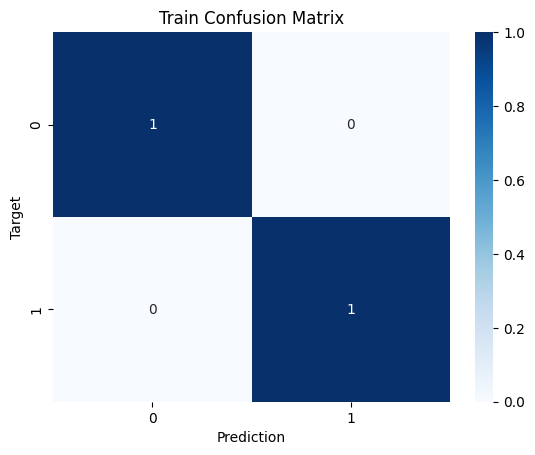

F1 score: 0.62%
Area under ROC score on Validation dataset: 0.77016%


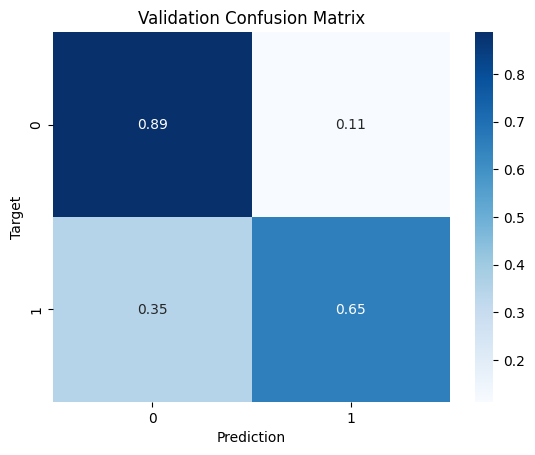

In [14]:
#Виведіть area under ROC для моделі на тренувальних і тестувальних даних.
train_preds = predict_and_plot(model,X_train, train_targets, 'Train')
val_preds = predict_and_plot(model,X_val, val_targets, 'Validation')

модель перенавчена, бо на тесті 100%, а на трейні 77%

In [15]:
#Виведіть глибину дерева.
model.tree_.max_depth

26

In [16]:
#Побудуйте дерево до глибини 2 включно. Напишіть, які ознаки бачите, що є найвпливовішими тут?
model_2 = DecisionTreeClassifier(max_depth=2, random_state=42)
model_2.fit(X_train, train_targets)


DecisionTreeClassifier(max_depth=2, random_state=42)

In [17]:
from sklearn.tree import plot_tree, export_text
tree_text = export_text(model_2, feature_names=list(X_train.columns))
print(tree_text[:5000])

|--- Age <= 0.71
|   |--- NumOfProducts <= -0.17
|   |   |--- class: 0.0
|   |--- NumOfProducts >  -0.17
|   |   |--- class: 0.0
|--- Age >  0.71
|   |--- NumOfProducts <= -0.17
|   |   |--- class: 1.0
|   |--- NumOfProducts >  -0.17
|   |   |--- class: 0.0



Найвпливовішими фічами є Age та NumOfProducts

In [18]:
#Створіть датафрейм importance_df з feature importances,
# першому стовпчику feature - назва ознаки з нашого Х
#другому importance - значення, наскільки ця ознака є важливою в побудованій моделі.
#Виведіть топ 10 найвпливовіших ознак разом з їх скором важливості (можна або у вигляді таблиці, або в вигляді barplot).


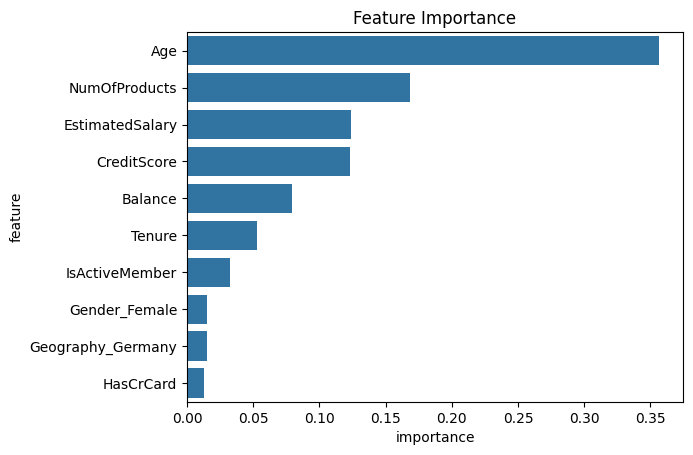

In [19]:
importance_df = pd.DataFrame({
    'feature': X_train.columns,
    'importance': model.feature_importances_
}).sort_values('importance', ascending=False)

plt.title('Feature Importance')
sns.barplot(data=importance_df.head(10), x='importance', y='feature');

**Завдання 3**. Спробуйте знайти такі параметри моделі `DecisionTree` аби модель генералізувала ліпше (був вищий показник AUROC на валідаційній вибірці). Проекспериментуйте з різними значеннями параметрів `max_leaf_nodes`, `max_depth` та лишіть ті, які дають найкращий результат, разом з відповідними AUROC на тренувальній і валідаційній вибірках.

В цьому завданні спробуйте просто знайти параметри методом "тика" :)

F1 score: 0.74%
Area under ROC score on Train dataset: 0.92978%


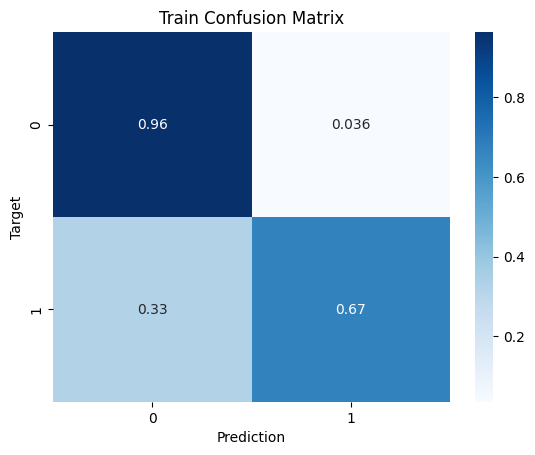

F1 score: 0.71%
Area under ROC score on Validation dataset: 0.92463%


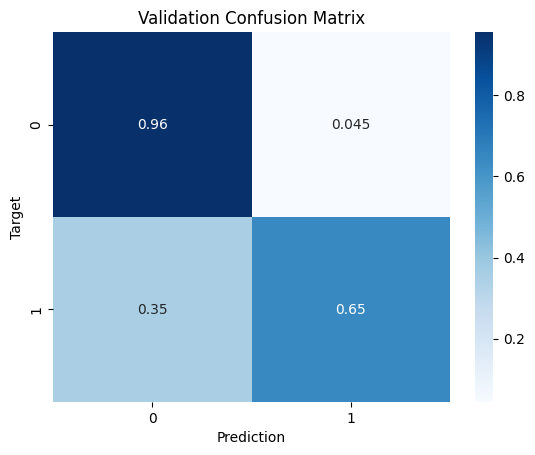

In [20]:
model_new = DecisionTreeClassifier(max_depth=7, max_leaf_nodes=40, random_state=42)
model_new.fit(X_train, train_targets)

train_preds = predict_and_plot(model_new,X_train, train_targets, 'Train')
val_preds = predict_and_plot(model_new,X_val, val_targets, 'Validation')

**Завдання 4**. В циклі пройдіться по значенням max_depth від 1 до 20 включно, на кожній ітерації натренуйте DecisionTree модель і виміряйте AUROC на трейн і валідаційних даних.

В кінці виведіть на графік залеєність між AUROC на трейн і валідаційних даних і номером ітерації.

In [21]:

from sklearn.metrics import roc_auc_score

def experiment_max_depth(data, max_range=20):
    """
    Тренує моделі DecisionTree з max_depth від 1 до max_range
    та візуалізує зміну AUROC.
    """
    train_auroc_scores = []
    val_auroc_scores = []
    depths = list(range(1, max_range + 1))

    for depth in depths:
        # 1. Ініціалізація та навчання моделі
        model = DecisionTreeClassifier(max_depth=depth, random_state=42)
        model.fit(data['X_train'], data['train_targets'])

        # 2. Прогноз ймовірностей для обох вибірок
        train_probs = model.predict_proba(data['X_train'])[:, 1]
        val_probs = model.predict_proba(data['X_val'])[:, 1]

        # 3. Обчислення AUROC
        train_auroc_scores.append(roc_auc_score(data['train_targets'], train_probs))
        val_auroc_scores.append(roc_auc_score(data['val_targets'], val_probs))

    # 4. Візуалізація результатів
    plt.figure(figsize=(10, 6))
    plt.plot(depths, train_auroc_scores, 'b-o', label='Train AUROC')
    plt.plot(depths, val_auroc_scores, 'r-o', label='Validation AUROC')

    plt.title('Залежність AUROC від max_depth')
    plt.xlabel('Max Depth (Номер ітерації)')
    plt.ylabel('AUROC Score')
    plt.xticks(depths)
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.show()

    return train_auroc_scores, val_auroc_scores




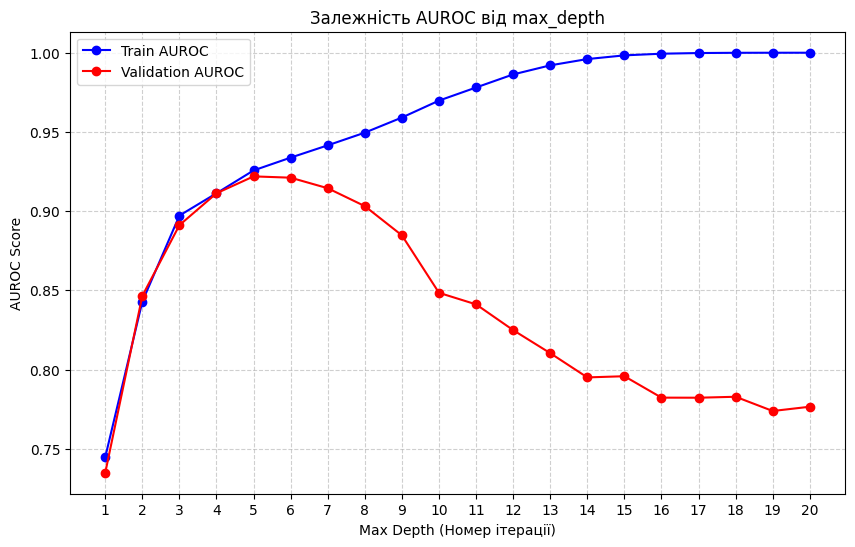

In [22]:
train_scores, val_scores = experiment_max_depth(dataset)

**Завдання 5**.
1. Натренуйте модель `DecisionTree` з найкращим значенням `max_depth`, яке ви знайшли на попередній ітерації.
2. Завантажте тестові дані змагання з `test.csv`.
3. Зробіть попередню обробку даних з функцією `preprocess_new_data` з вашого модуля `process_bank_churn.py`.
4. Зробіть передбачення використовуючи цю модель на тестових даних змагання.
5. Сформуйте `submission.csv`.
6. Зробіть новий Submission на Kaggle і додайте тут скріншот Вашого скору на паблік лідерборді :)


In [35]:
#переррахунок для змагань
raw_df_test = pd.read_csv('test.csv', index_col=0)
raw_df_test.head()

,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary
id,,,,,,,,,,,,
15000,15594796.0,Chu,584.0,Germany,Male,30.0,2.0,146053.66,1.0,1.0,1.0,157891.86
15001,15642821.0,Mazzi,551.0,France,Male,39.0,5.0,0.00,2.0,1.0,1.0,67431.28
15002,15716284.0,Onyekachi,706.0,France,Male,43.0,8.0,0.00,2.0,1.0,0.0,156768.45
15003,15785078.0,Martin,717.0,Spain,Male,45.0,3.0,0.00,1.0,1.0,1.0,166909.87
15004,15662955.0,Kenechukwu,592.0,Spain,Male,43.0,8.0,0.00,2.0,1.0,1.0,143681.97


In [36]:
from process_bank_churn_new import preprocess_new_data
X_test = preprocess_new_data(raw_df_test, dataset['input_cols'], dataset['scaler'], dataset['encoder'])
X_test.head()

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Geography_France,Geography_Germany,Geography_Spain,Gender_Female,Gender_Male
id,,,,,,,,,,,,,
15000,-1.034678,-0.944682,-1.087792,1.720173,-1.108193,0.515062,1.016977,0.875226,0.0,1.0,0.0,0.0,1.0
15001,-1.490909,0.161227,-0.009376,-0.717950,0.769304,0.515062,1.016977,-1.109098,1.0,0.0,0.0,0.0,1.0
15002,0.651991,0.652742,1.069040,-0.717950,0.769304,0.515062,-0.983306,0.850584,1.0,0.0,0.0,0.0,1.0
15003,0.804068,0.898500,-0.728320,-0.717950,-1.108193,0.515062,1.016977,1.073044,0.0,0.0,1.0,0.0,1.0
15004,-0.924077,0.652742,1.069040,-0.717950,0.769304,0.515062,1.016977,0.563521,0.0,0.0,1.0,0.0,1.0


In [37]:
model_final = DecisionTreeClassifier(
    max_depth=5,
    random_state=42
)
model_final.fit(X_train, train_targets)

test_proba = model_final.predict_proba(X_test)[:, 1]
raw_df_test['Exited']=model_final.predict_proba(X_test)[:, 1]
raw_df_test = raw_df_test.reset_index().rename(columns={'index': 'id'})
raw_df_test.head()

,id,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,15000,15594796.0,Chu,584.0,Germany,Male,30.0,2.0,146053.66,1.0,1.0,1.0,157891.86,0.237911
1,15001,15642821.0,Mazzi,551.0,France,Male,39.0,5.0,0.00,2.0,1.0,1.0,67431.28,0.027613
2,15002,15716284.0,Onyekachi,706.0,France,Male,43.0,8.0,0.00,2.0,1.0,0.0,156768.45,0.027613
3,15003,15785078.0,Martin,717.0,Spain,Male,45.0,3.0,0.00,1.0,1.0,1.0,166909.87,0.770925
4,15004,15662955.0,Kenechukwu,592.0,Spain,Male,43.0,8.0,0.00,2.0,1.0,1.0,143681.97,0.027613


In [39]:
sample_submission  = pd.read_csv('sample_submission.csv')
sample_submission['Exited'] = sample_submission['id'].map(raw_df_test.set_index('id')['Exited'])
sample_submission.head()
sample_submission.to_csv('sample_submission_new_tree.csv', index=False)

Скрін скорів, позиція на лідерборді після цієї моделі не змінилась

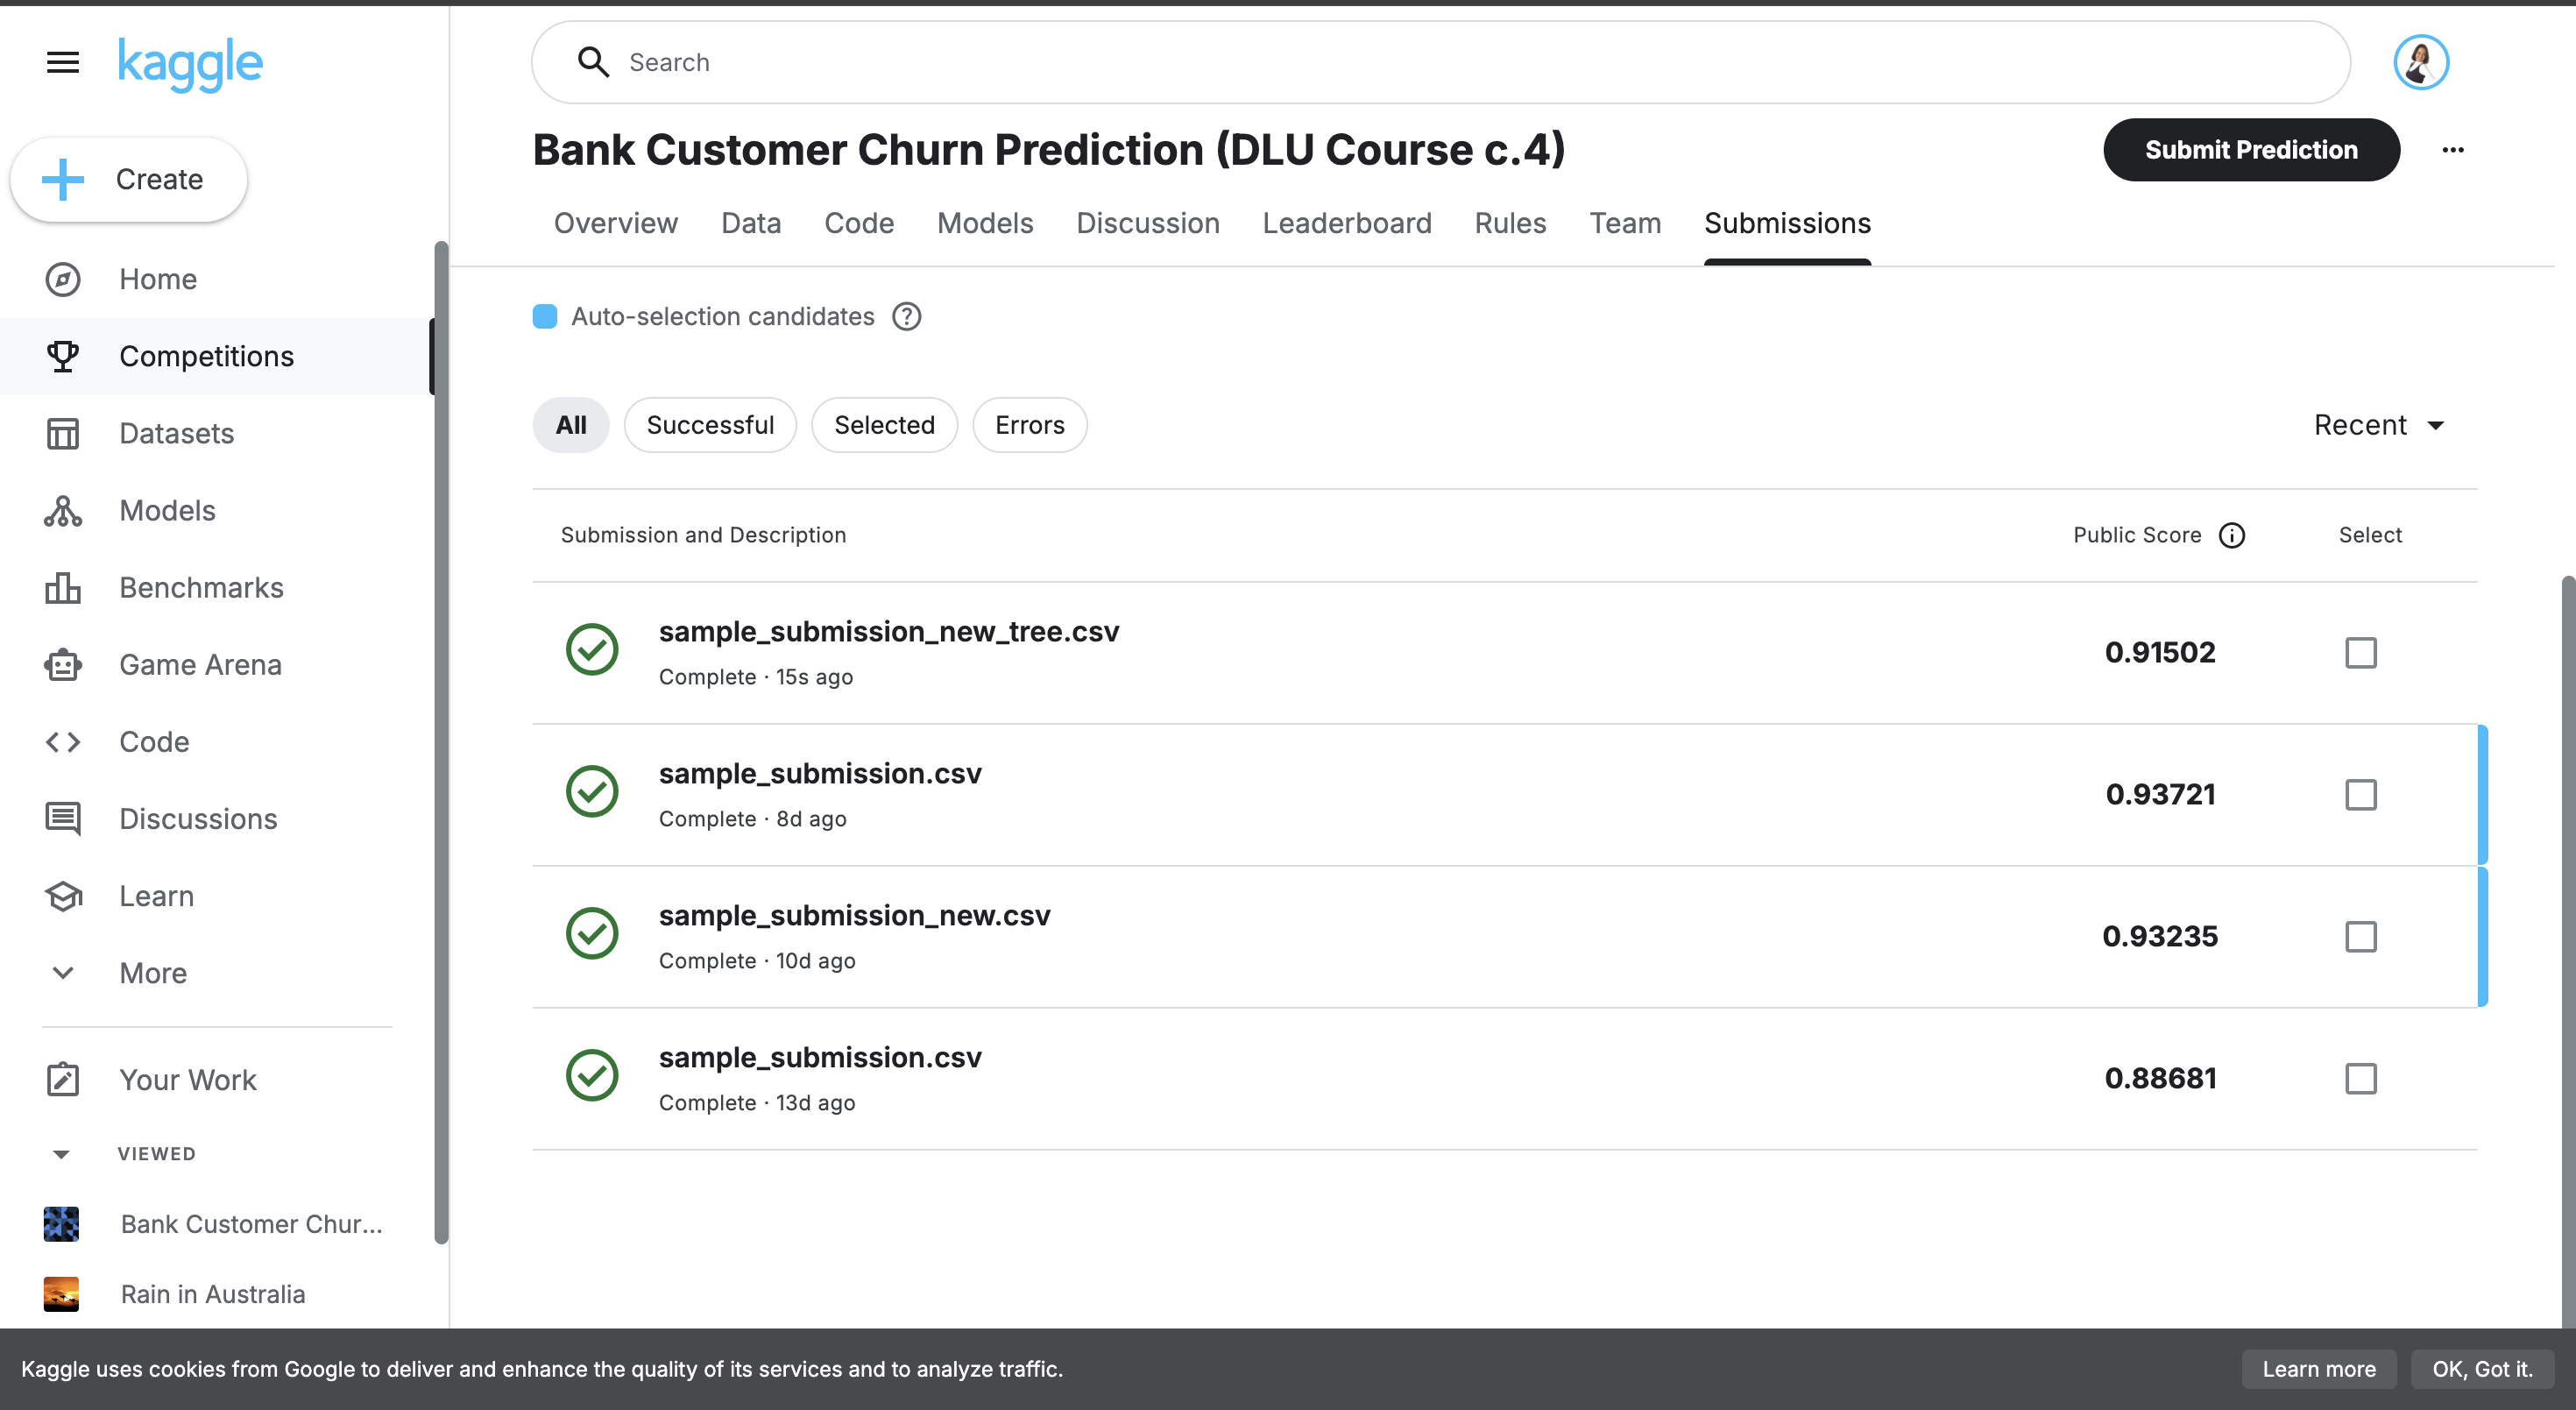

###Висновок
Додала новий файл до змагання, але як і було попердньо зрозуміло - модель предіктить гірше ніж моя остання спроба логістичної регресія з поліноміальними ознаками та регуляризацією. Та і загалом цей результат кращий на даний момент лише за першу модель на курсі.

Загалом якщо додати до вибору накращих параметрів ще й max_leaf_nodes, то результат буде іншим. Нижче реалізація підбору і найкращий результат.
Вручну вдалось досягти майже такий самий результат як і при підборі найкращих параметрів max_depth та max_leaf_nodes.


In [40]:
def hyperparameter_experiment(data):
    """
    Проводить експеримент з перебором max_depth (1-20) та
    max_leaf_nodes (від 2 до 60 з кроком 5).
    """
    train_auroc_list = []
    val_auroc_list = []
    iterations = []

    # Визначаємо сітку параметрів
    depths = range(1, 21)
    leaf_nodes_range = range(2, 61, 5) # від 2 до 60 з кроком 5 для наочності графіка

    counter = 0
    best_val_auc = 0
    best_params = {}

    print(f"{'Iter':<5} | {'Depth':<5} | {'Leaves':<7} | {'Train AUC':<10} | {'Val AUC':<10}")
    print("-" * 50)

    for depth in depths:
        for leaves in leaf_nodes_range:
            counter += 1

            # 1. Навчання моделі
            model = DecisionTreeClassifier(
                max_depth=depth,
                max_leaf_nodes=leaves,
                random_state=42
            )
            model.fit(data['X_train'], data['train_targets'])

            # 2. Обчислення метрик
            train_auc = roc_auc_score(data['train_targets'], model.predict_proba(data['X_train'])[:, 1])
            val_auc = roc_auc_score(data['val_targets'], model.predict_proba(data['X_val'])[:, 1])

            # Зберігаємо результати
            train_auroc_list.append(train_auc)
            val_auroc_list.append(val_auc)
            iterations.append(counter)

            # Пошук найкращого результату
            if val_auc > best_val_auc:
                best_val_auc = val_auc
                best_params = {'depth': depth, 'leaves': leaves, 'auc': val_auc}

            if counter % 20 == 0: # Виводимо кожен 20-й крок, щоб не засмічувати консоль
                print(f"{counter:<5} | {depth:<5} | {leaves:<7} | {train_auc:.4f}    | {val_auc:.4f}")

    # 3. Візуалізація
    plt.figure(figsize=(12, 6))
    plt.plot(iterations, train_auroc_list, label='Train AUROC', alpha=0.7, color='blue')
    plt.plot(iterations, val_auroc_list, label='Validation AUROC', alpha=0.9, color='red')

    plt.title('Залежність AUROC від ітерації (комбінації Depth та Leaf Nodes)')
    plt.xlabel('Номер ітерації')
    plt.ylabel('AUROC Score')
    plt.axvline(x=iterations[val_auroc_list.index(best_val_auc)], color='green', linestyle='--', label='Best Val AUC')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

    print(f"\nНайкращі параметри: Depth={best_params['depth']}, Leaves={best_params['leaves']} з AUC={best_params['auc']:.4f}")

    return

Iter  | Depth | Leaves  | Train AUC  | Val AUC   
--------------------------------------------------
20    | 2     | 37      | 0.8429    | 0.8465
40    | 4     | 17      | 0.9113    | 0.9113
60    | 5     | 57      | 0.9257    | 0.9219
80    | 7     | 37      | 0.9285    | 0.9241
100   | 9     | 17      | 0.9152    | 0.9154
120   | 10    | 57      | 0.9324    | 0.9199
140   | 12    | 37      | 0.9284    | 0.9234
160   | 14    | 17      | 0.9152    | 0.9154
180   | 15    | 57      | 0.9324    | 0.9199
200   | 17    | 37      | 0.9284    | 0.9234
220   | 19    | 17      | 0.9152    | 0.9154
240   | 20    | 57      | 0.9324    | 0.9199


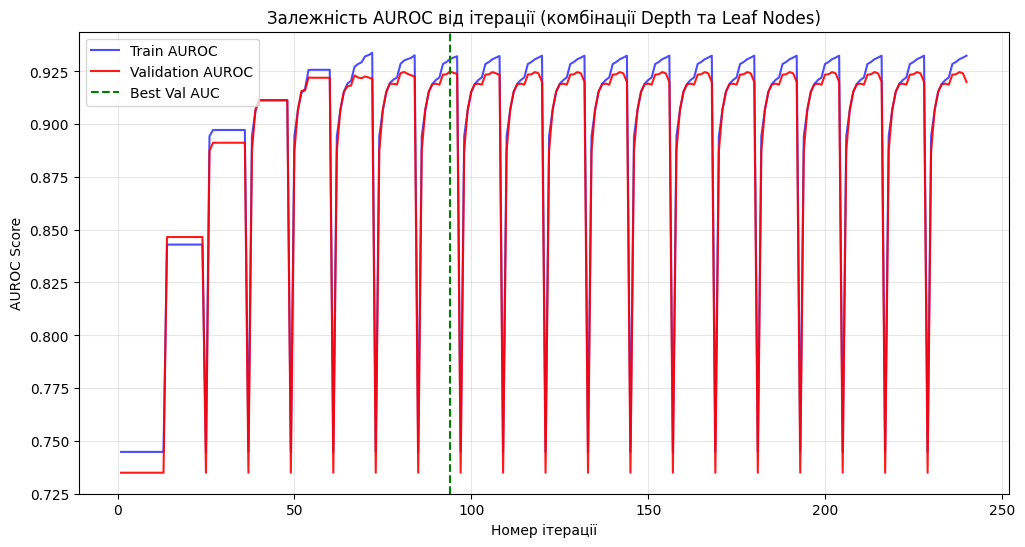


Найкращі параметри: Depth=8, Leaves=47 з AUC=0.9249


In [41]:
hyperparameter_experiment(dataset)